# Day 10 — Federated learning baseline (FedAvg)

Simulated federated training of the frozen `centralized_cnn_v1` architecture with standard FedAvg. The **only** new variable relative to the centralized baseline is federated training. Data, labels, preprocessing, split, model, and evaluation protocol are unchanged.

- Clients are built only from the existing **training** groups (whole inferred subject-equivalence groups, never individual windows).
- The global model is evaluated on the **validation** split after every round; the round with minimum validation loss is selected (the same rule as the centralized baseline).
- The **test** split is evaluated **once**, after selection, inside `run_experiment`.

This is a simulation on public data: the clients are not real hospitals, raw ECG stays inside each simulated client's process-local dataset, and no privacy guarantee or blockchain functionality is part of this experiment. Full description: `docs/federated_learning_baseline.md`.

In [1]:
from pathlib import Path
import hashlib, json, os, sys
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if not (ROOT / 'configs/federated/fedavg_v1.json').exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
pd.set_option('display.width', 200, 'display.max_columns', 30)

from src.federated.config import load_federated_config
from src.federated.run_fedavg import prepare_partition, run_experiment
from src.federated.evaluation import communication_cost
from src.federated.fedavg import get_model_state
from src.models.cnn1d import ECG1DCNN, count_trainable_parameters

## 1. Configuration

In [2]:
CONFIG_PATH = 'configs/federated/fedavg_v1.json'
config = load_federated_config(CONFIG_PATH)
print(json.dumps(config, indent=2))

{
  "experiment_id": "fedavg_v1",
  "random_seed": 42,
  "model": {
    "architecture": "centralized_cnn_v1",
    "class": "src.models.cnn1d.ECG1DCNN",
    "dropout": 0.3
  },
  "data": {
    "split_root": "data/splits/mitbih_v1",
    "label_config": "configs/preprocessing/mitbih_v1.json"
  },
  "partition": {
    "strategy": "random_group_equal_count",
    "num_clients": 5,
    "seed": 42,
    "min_client_segments": 1000
  },
  "training": {
    "rounds": 20,
    "local_epochs": 1,
    "batch_size": 256,
    "learning_rate": 0.001,
    "optimizer": "Adam",
    "loss": "CrossEntropyLoss",
    "shuffle_training": true,
    "client_optimizer_state": "reset_each_round"
  },
  "participation": {
    "fraction": 1.0
  },
  "aggregation": {
    "method": "FedAvg",
    "weighting": "client_training_samples"
  },
  "model_selection": {
    "split": "validation",
    "metric": "validation_loss",
    "mode": "min"
  },
  "runtime": {
    "device": "cpu",
    "cpu_threads": 8,
    "num_workers": 

## 2. Client distribution

Partition preview (nothing is written here; `run_experiment` writes the same partition). The 33 training groups are permuted with seed 42 and cut into five contiguous chunks of 7/7/7/6/6 groups. No balancing is applied, so each client keeps the natural class mix of its records.

In [3]:
partition, summary, counts, proportions = prepare_partition(config, write=False)
display(pd.DataFrame(summary))
display(pd.DataFrame(counts).set_index('client_id'))
display(pd.DataFrame(proportions).set_index('client_id').round(4))

,client_id,groups,records,segments,share_of_training_segments,classes_present,classes_absent,record_ids
0,client_00,7,7,16406,0.211554,9,/ E L a e f,108 115 118 205 208 228 234
1,client_01,7,7,18698,0.241109,8,/ J Q R S f j,109 210 213 215 220 223 230
2,client_02,7,7,16563,0.213578,11,J S e j,102 105 117 203 207 209 221
3,client_03,6,6,13946,0.179832,7,/ E L Q S a e f,121 122 200 212 222 232
4,client_04,6,6,11937,0.153926,10,E L S a e,103 104 106 116 124 231


,/,A,E,F,J,L,N,Q,R,S,V,a,e,f,j,total
client_id,,,,,,,,,,,,,,,,
client_00,0,106,0,385,50,0,12234,2,2165,2,1461,0,0,0,1,16406
client_01,0,194,1,389,0,2491,14491,0,0,0,1090,26,16,0,0,18698
client_02,2028,491,105,1,0,1457,11338,9,85,0,991,2,0,56,0,16563
client_03,0,1621,0,2,1,0,9060,0,2222,0,827,0,0,0,213,13946
client_04,1379,6,0,5,29,0,6366,18,2783,0,680,0,0,666,5,11937


,/,A,E,F,J,L,N,Q,R,S,V,a,e,f,j
client_id,,,,,,,,,,,,,,,
client_00,0.0000,0.0065,0.0000,0.0235,0.0030,0.0000,0.7457,0.0001,0.1320,0.0001,0.0891,0.0000,0.0000,0.0000,0.0001
client_01,0.0000,0.0104,0.0001,0.0208,0.0000,0.1332,0.7750,0.0000,0.0000,0.0000,0.0583,0.0014,0.0009,0.0000,0.0000
client_02,0.1224,0.0296,0.0063,0.0001,0.0000,0.0880,0.6845,0.0005,0.0051,0.0000,0.0598,0.0001,0.0000,0.0034,0.0000
client_03,0.0000,0.1162,0.0000,0.0001,0.0001,0.0000,0.6496,0.0000,0.1593,0.0000,0.0593,0.0000,0.0000,0.0000,0.0153
client_04,0.1155,0.0005,0.0000,0.0004,0.0024,0.0000,0.5333,0.0015,0.2331,0.0000,0.0570,0.0000,0.0000,0.0558,0.0004


## 3. Global model initialization and per-round payload

In [4]:
model = ECG1DCNN(dropout=config['model']['dropout'])
state = get_model_state(model)
print('Trainable parameters:', count_trainable_parameters(model))
print('State-dict entries:', len(state))
preview = communication_cost(state, [config['partition']['num_clients']], count_trainable_parameters(model))
print('Payload bytes per model transfer:', preview['payload_bytes_per_model'])

Trainable parameters: 10127
State-dict entries: 20
Payload bytes per model transfer: 41428


## 4–6. Run FedAvg, validate after each round, evaluate the selected global model once on test

This cell is the single official execution of `fedavg_v1`. It refuses to overwrite an existing run.

In [5]:
summary_run = run_experiment(CONFIG_PATH, evaluate_test=True)
print('Selected round (min validation loss):', summary_run['selected_round_by_validation_loss'])
print('Training time (s): %.1f' % summary_run['training_elapsed_seconds'])

Clients: [16406, 18698, 16563, 13946, 11937] segments; validation: 16351


{"round": 1, "participants": 5, "client_train_loss_weighted": 1.4695, "client_train_accuracy_weighted": 0.766, "elapsed_seconds": 5.5327, "validation_loss": 1.5478, "validation_accuracy": 0.6937, "validation_macro_f1": 0.0546, "validation_weighted_f1": 0.5682, "validation_macro_precision": 0.0462, "validation_macro_recall": 0.0667}


{"round": 2, "participants": 5, "client_train_loss_weighted": 0.6175, "client_train_accuracy_weighted": 0.8462, "elapsed_seconds": 11.0952, "validation_loss": 1.2206, "validation_accuracy": 0.6878, "validation_macro_f1": 0.0787, "validation_weighted_f1": 0.613, "validation_macro_precision": 0.0668, "validation_macro_recall": 0.1094}


{"round": 3, "participants": 5, "client_train_loss_weighted": 0.4455, "client_train_accuracy_weighted": 0.8908, "elapsed_seconds": 17.2106, "validation_loss": 1.1894, "validation_accuracy": 0.6912, "validation_macro_f1": 0.0814, "validation_weighted_f1": 0.617, "validation_macro_precision": 0.0687, "validation_macro_recall": 0.1172}


{"round": 4, "participants": 5, "client_train_loss_weighted": 0.3669, "client_train_accuracy_weighted": 0.912, "elapsed_seconds": 22.8533, "validation_loss": 1.2192, "validation_accuracy": 0.7022, "validation_macro_f1": 0.0889, "validation_weighted_f1": 0.6278, "validation_macro_precision": 0.0744, "validation_macro_recall": 0.1266}


...

{"round": 17, "participants": 5, "client_train_loss_weighted": 0.2008, "client_train_accuracy_weighted": 0.9527, "elapsed_seconds": 97.2504, "validation_loss": 1.4498, "validation_accuracy": 0.6892, "validation_macro_f1": 0.0845, "validation_weighted_f1": 0.6285, "validation_macro_precision": 0.0722, "validation_macro_recall": 0.1273}


{"round": 18, "participants": 5, "client_train_loss_weighted": 0.1986, "client_train_accuracy_weighted": 0.953, "elapsed_seconds": 103.0057, "validation_loss": 1.4494, "validation_accuracy": 0.6324, "validation_macro_f1": 0.0818, "validation_weighted_f1": 0.5945, "validation_macro_precision": 0.0712, "validation_macro_recall": 0.1218}


{"round": 19, "participants": 5, "client_train_loss_weighted": 0.1967, "client_train_accuracy_weighted": 0.9535, "elapsed_seconds": 108.4409, "validation_loss": 1.4676, "validation_accuracy": 0.6248, "validation_macro_f1": 0.0794, "validation_weighted_f1": 0.6029, "validation_macro_precision": 0.0715, "validation_macro_recall": 0.1211}


{"round": 20, "participants": 5, "client_train_loss_weighted": 0.1922, "client_train_accuracy_weighted": 0.955, "elapsed_seconds": 114.5355, "validation_loss": 1.6317, "validation_accuracy": 0.5907, "validation_macro_f1": 0.0774, "validation_weighted_f1": 0.5757, "validation_macro_precision": 0.07, "validation_macro_recall": 0.118}


Selected round (min validation loss): 3
Training time (s): 115.0


### Validation metrics by communication round (round 0 = initial global model)

In [6]:
history = pd.read_csv('results/metrics/federated/fedavg_v1_round_history.csv')
display(history.round(4))

,round,participants,client_train_loss_weighted,client_train_accuracy_weighted,elapsed_seconds,validation_loss,validation_accuracy,validation_macro_f1,validation_weighted_f1,validation_macro_precision,validation_macro_recall
0,0,0,NaN,NaN,0.0000,2.6343,0.6937,0.0546,0.5682,0.0462,0.0667
1,1,5,1.4695,0.7660,5.5327,1.5478,0.6937,0.0546,0.5682,0.0462,0.0667
2,2,5,0.6175,0.8462,11.0952,1.2206,0.6878,0.0787,0.6130,0.0668,0.1094
3,3,5,0.4455,0.8908,17.2106,1.1894,0.6912,0.0814,0.6170,0.0687,0.1172
4,4,5,0.3669,0.9120,22.8533,1.2192,0.7022,0.0889,0.6278,0.0744,0.1266
5,5,5,0.3180,0.9240,28.4069,1.3090,0.6959,0.0874,0.6245,0.0733,0.1281
6,6,5,0.2904,0.9304,33.8596,1.3707,0.7094,0.0904,0.6324,0.0754,0.1292
7,7,5,0.2652,0.9360,39.6365,1.4102,0.7014,0.0889,0.6280,0.0744,0.1285
8,8,5,0.2486,0.9398,45.5966,1.4122,0.7143,0.0913,0.6352,0.0760,0.1295
9,9,5,0.2375,0.9440,51.1816,1.4795,0.7003,0.0911,0.6290,0.0763,0.1284


### Held-out test metrics (evaluated once)

In [7]:
test = json.loads(Path('results/metrics/federated/fedavg_v1_test_metrics.json').read_text())
display(pd.Series(test['metrics']).to_frame('fedavg_v1'))
display(pd.read_csv('results/tables/federated/fedavg_v1_per_class_metrics.csv').round(4))
display(pd.read_csv('results/tables/federated/fedavg_v1_confusion_matrix.csv', index_col=0))

,fedavg_v1
accuracy,0.706858
auroc_defined_class_count,8.000000
class_count,15.000000
macro_auroc_ovr_defined_classes,0.673319
macro_f1,0.084846
macro_precision,0.075909
macro_recall_all_15_labels_zero_for_no_support,0.117694
macro_sensitivity_supported_classes,0.220677
macro_specificity_all_classes,0.974550
micro_auroc_ovr_flattened,0.972050


,label,precision,recall,sensitivity,specificity,f1_score,support,auroc_ovr,auroc_defined
0,/,0.0000,0.0000,0.0000,1.0000,0.0000,2078,0.9952,True
1,A,0.0000,0.0000,0.0000,1.0000,0.0000,50,0.7678,True
2,E,0.0000,0.0000,NaN,1.0000,0.0000,0,NaN,False
3,F,0.0000,0.0000,0.0000,1.0000,0.0000,13,0.4351,True
4,J,0.0000,0.0000,NaN,1.0000,0.0000,0,NaN,False
5,L,0.0000,0.0000,0.0000,1.0000,0.0000,2001,0.9913,True
6,N,0.9484,0.9861,0.9861,0.8980,0.9669,10197,0.9747,True
7,Q,0.0000,0.0000,0.0000,1.0000,0.0000,4,0.1410,True
8,R,0.0000,0.0000,NaN,1.0000,0.0000,0,NaN,False
9,S,0.0000,0.0000,NaN,1.0000,0.0000,0,NaN,False


,/,A,E,F,J,L,N,Q,R,S,V,a,e,f,j
true_label,,,,,,,,,,,,,,,
/,0,0,0,0,0,0,178,0,0,0,1900,0,0,0,0
A,0,0,0,0,0,0,49,0,0,0,1,0,0,0,0
E,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
F,0,0,0,0,0,0,8,0,0,0,5,0,0,0,0
J,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
L,0,0,0,0,0,0,40,0,0,0,1961,0,0,0,0
N,0,0,0,0,0,0,10055,0,0,0,142,0,0,0,0
Q,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0
R,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 7. Convergence and client figures

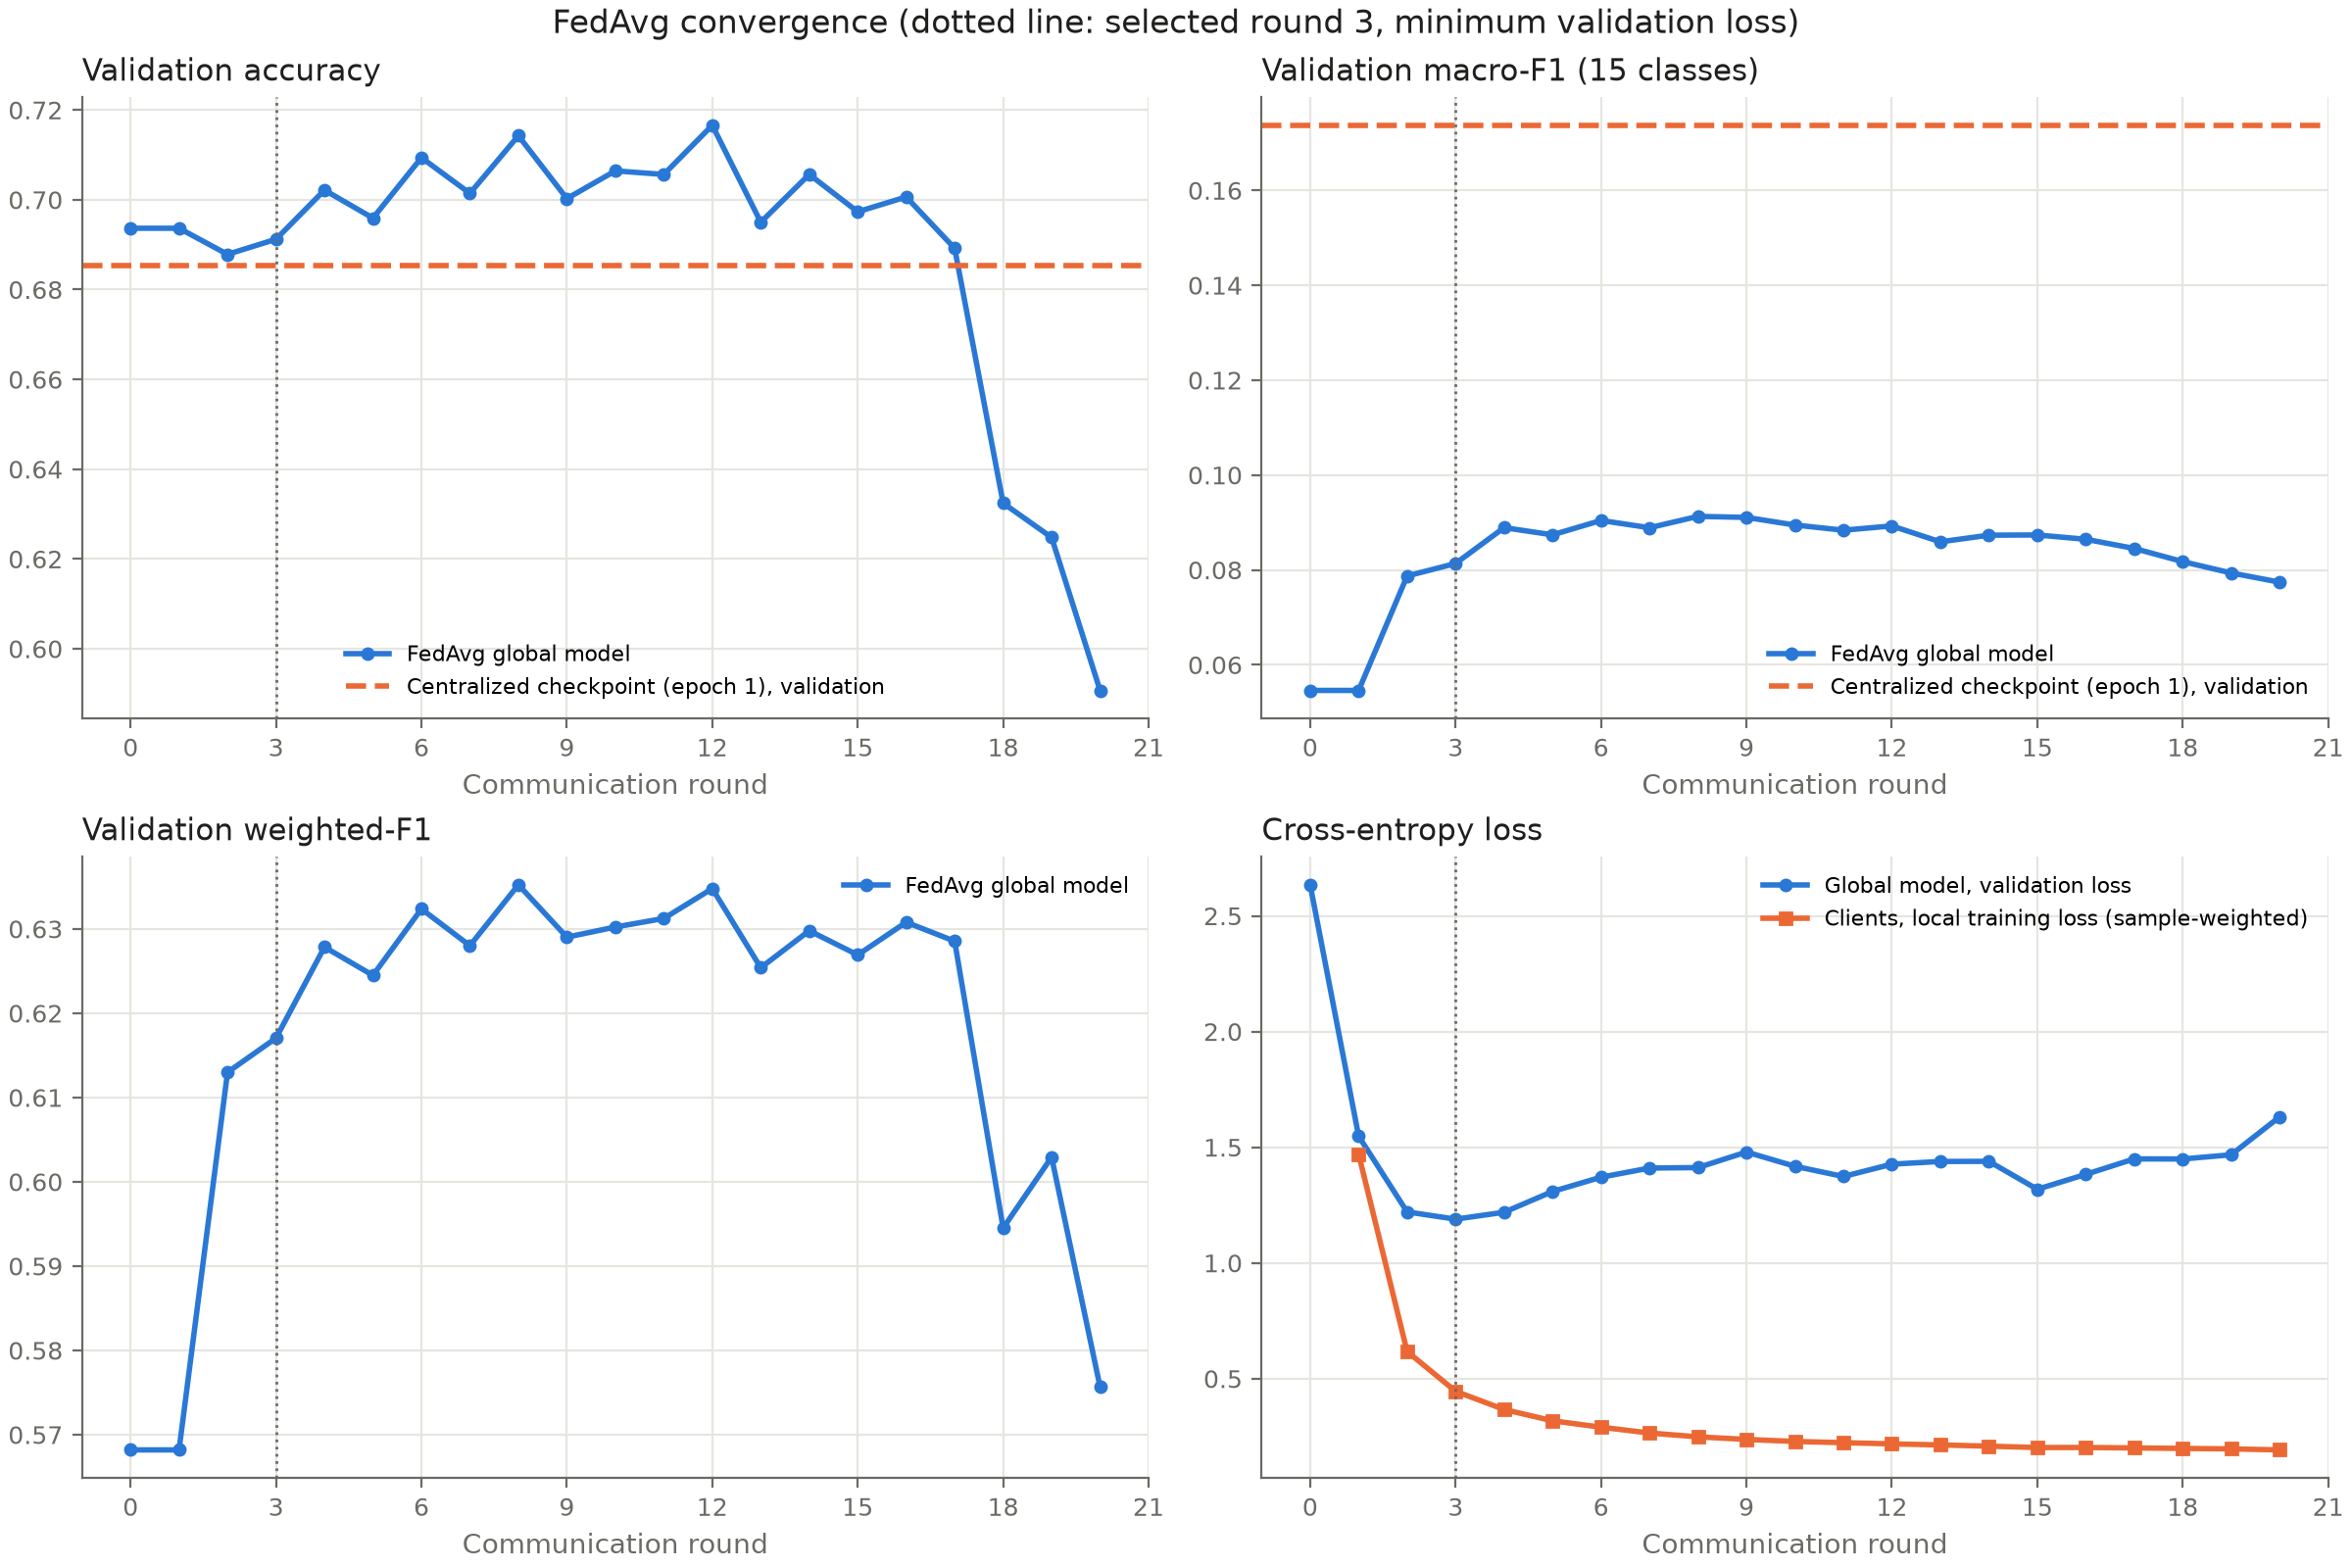

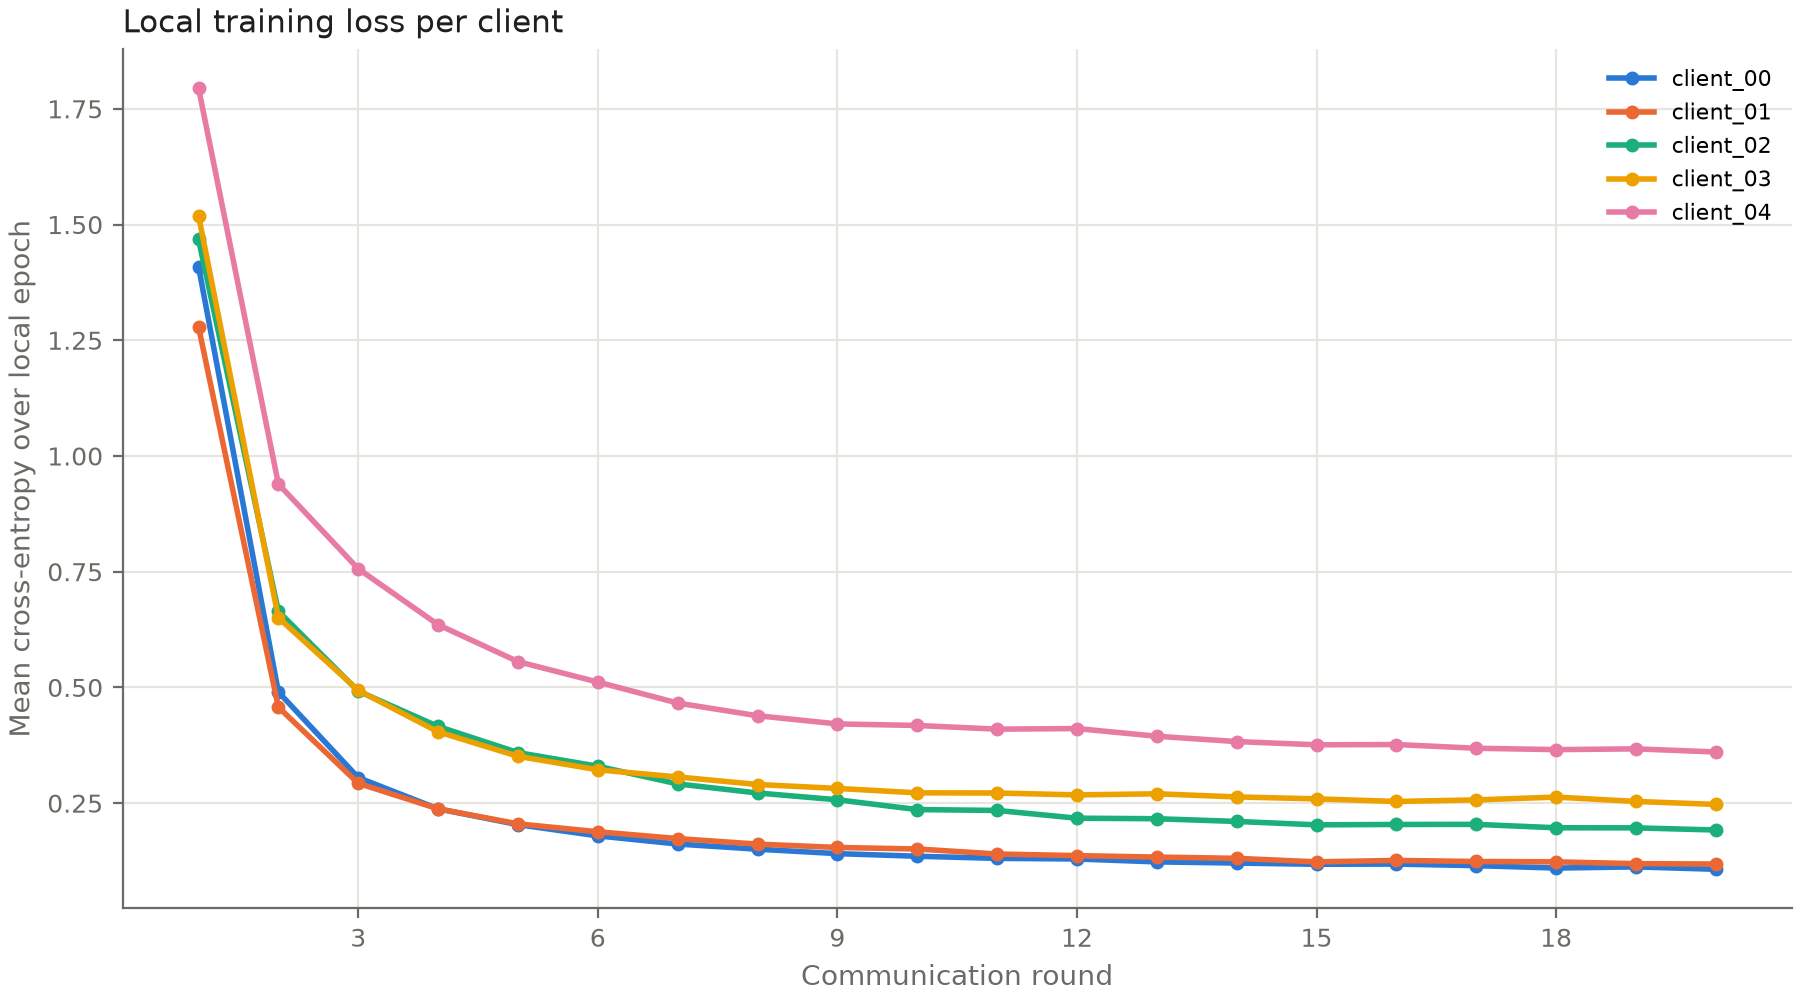

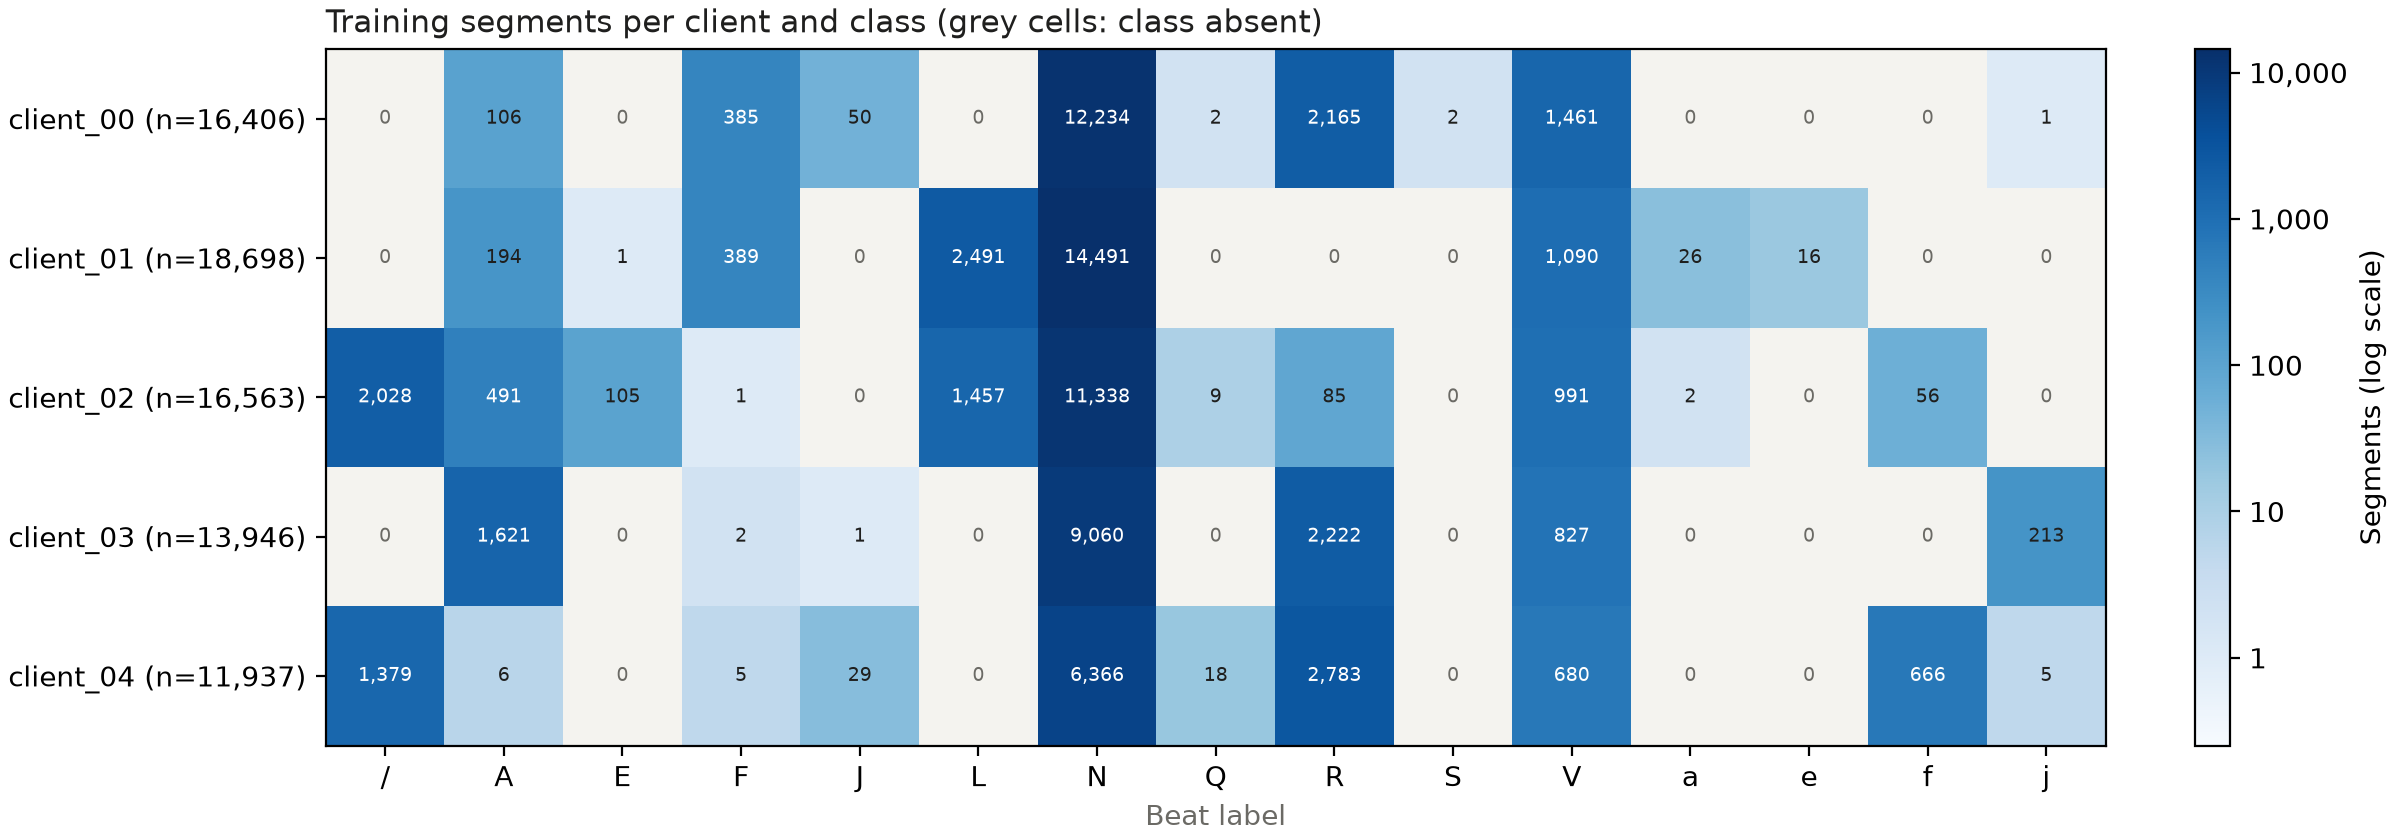

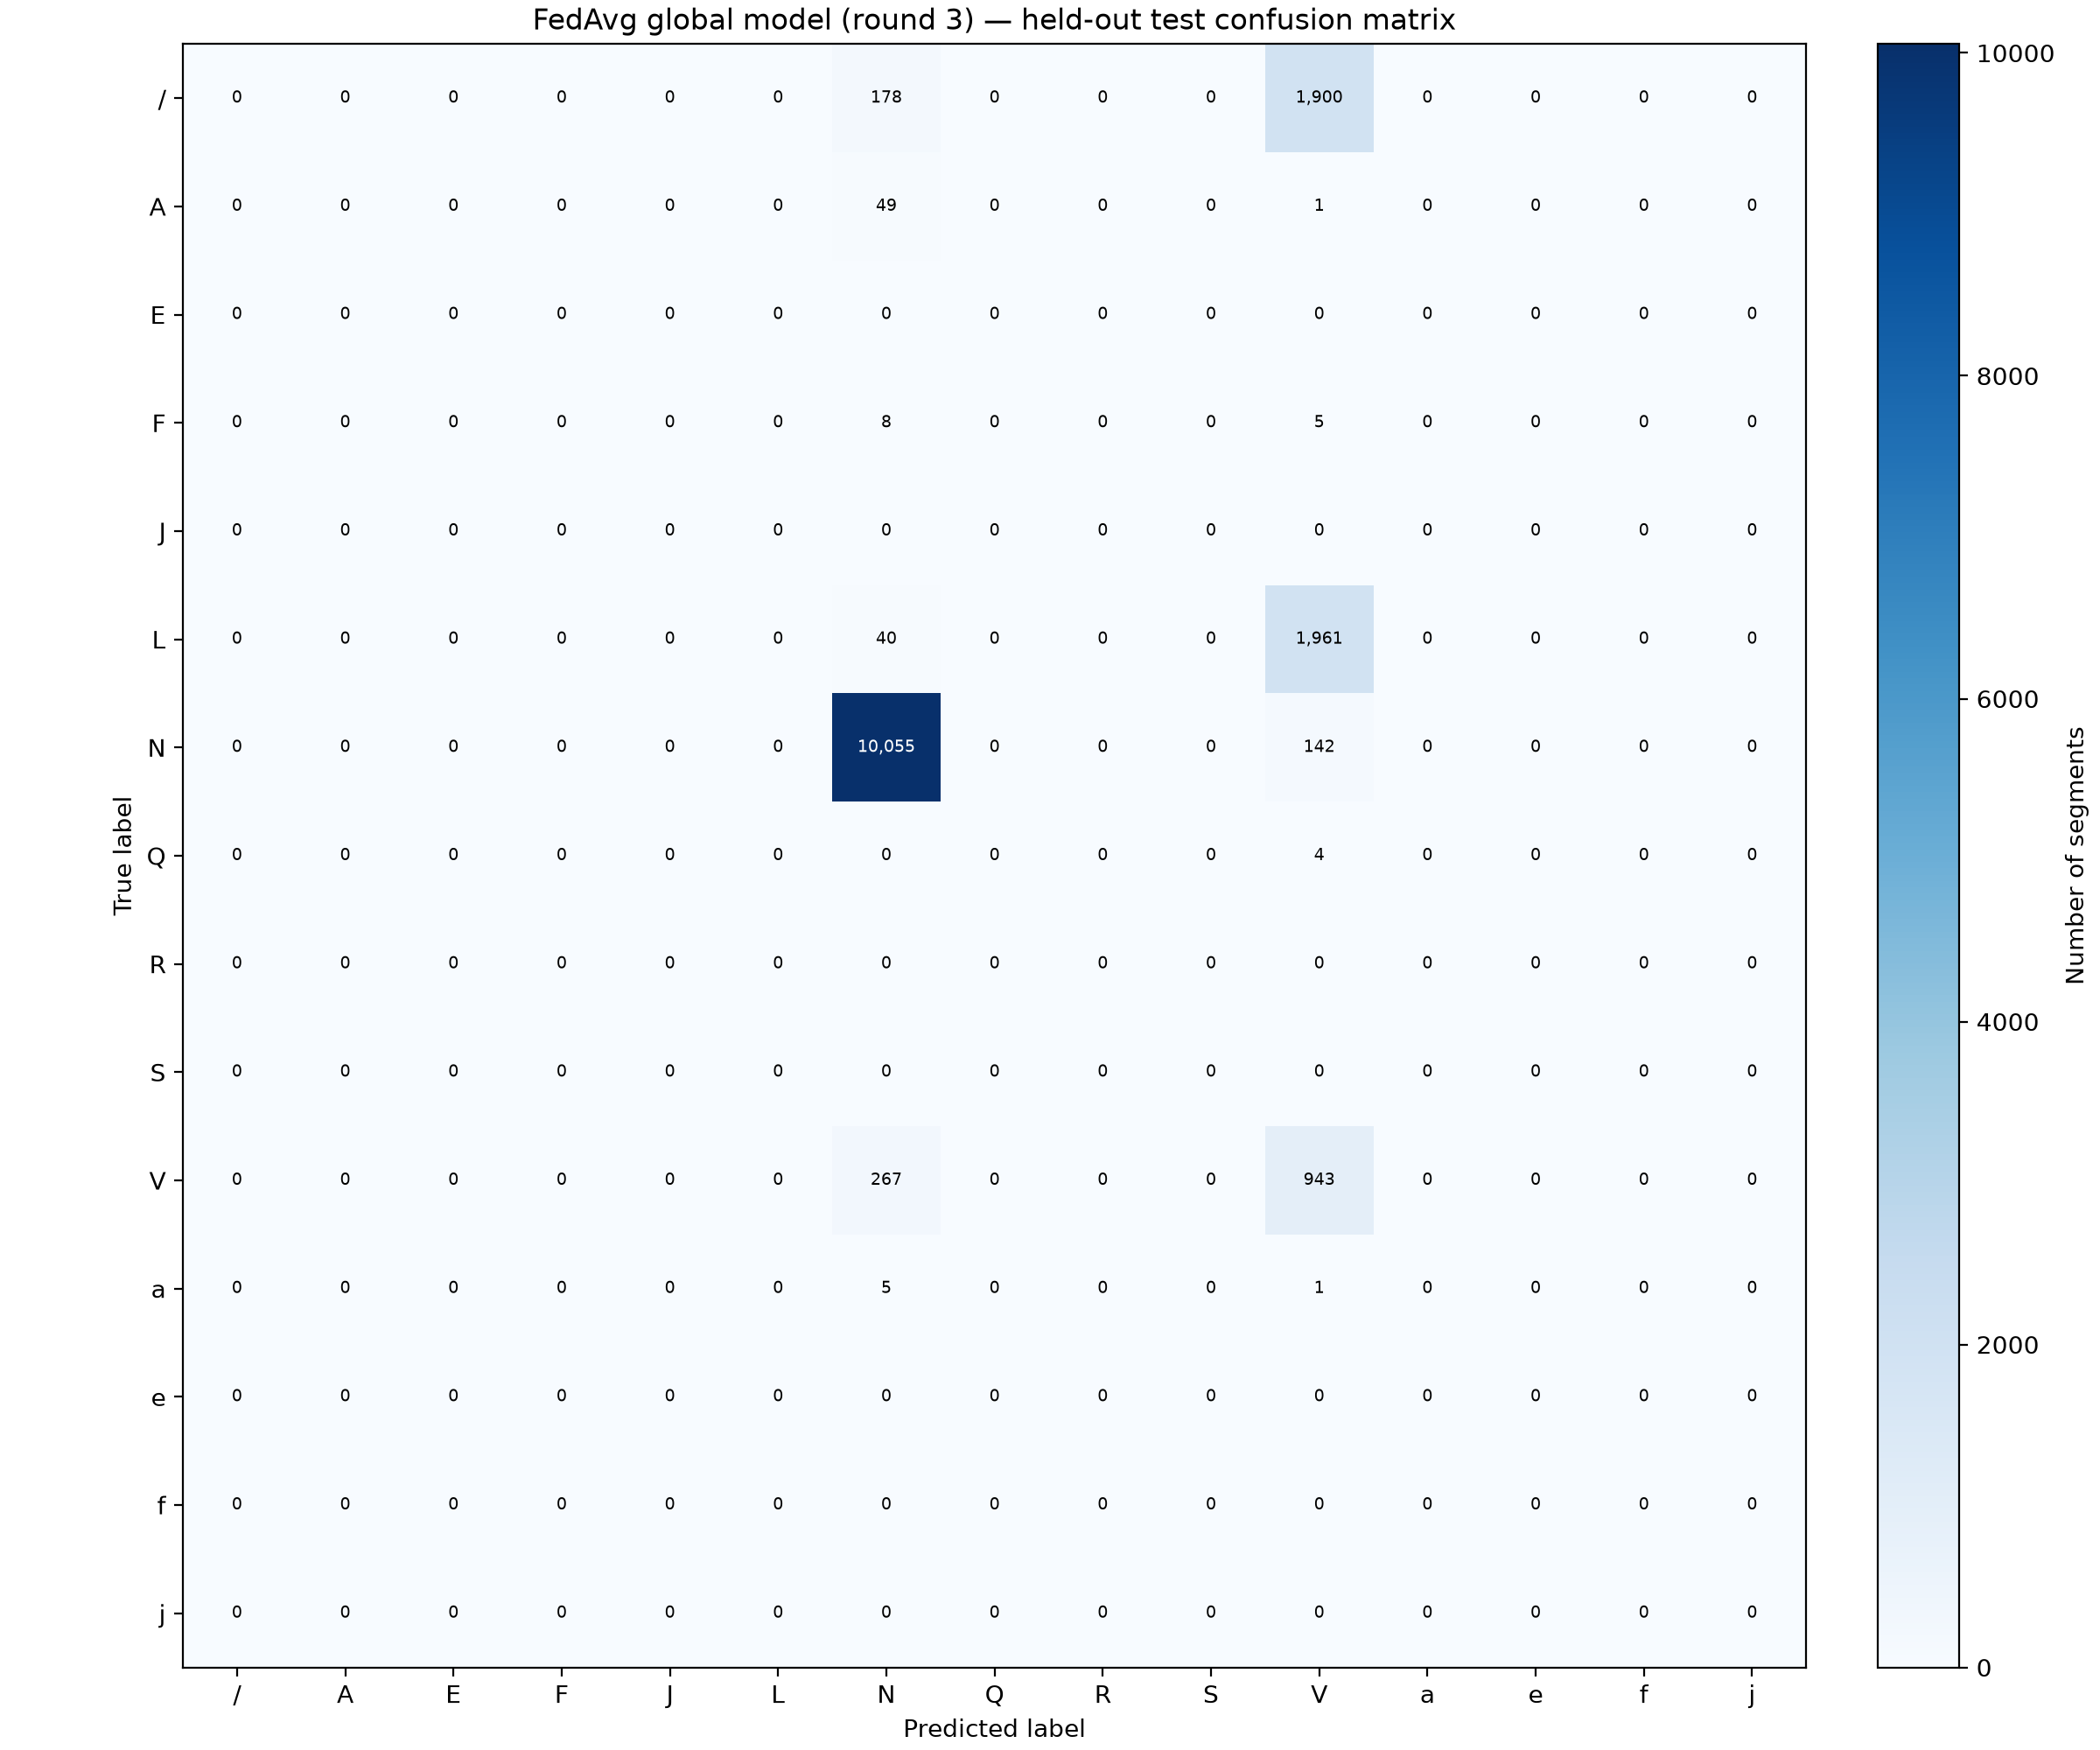

In [8]:
for name in ['fedavg_v1_convergence.png', 'fedavg_v1_client_losses.png', 'fedavg_v1_client_distribution.png',
             'fedavg_v1_confusion_matrix.png']:
    display(Image(filename=f'results/figures/federated/{name}', width=900))

## 8. Comparison with the frozen centralized baseline

Centralized values are read from the frozen Day 6 artifacts. "matches" means |Δ| < 0.01; this is a descriptive band, not a statistical test (single run, no confidence intervals).

In [9]:
display(pd.read_csv('results/tables/federated/centralized_vs_fedavg_aggregate.csv').round(4))
display(pd.read_csv('results/tables/federated/centralized_vs_fedavg_per_class.csv').round(4))

,metric,centralized_cnn_v1,fedavg_v1,delta_fedavg_minus_central,verdict
0,accuracy,0.7688,0.7069,-0.0620,degrades
1,macro_precision,0.1510,0.0759,-0.0751,degrades
2,macro_recall_all_15_labels_zero_for_no_support,0.1431,0.1177,-0.0254,degrades
3,macro_sensitivity_supported_classes,0.2683,0.2207,-0.0476,degrades
4,macro_f1,0.1399,0.0848,-0.0550,degrades
5,weighted_precision,0.7078,0.6364,-0.0714,degrades
6,weighted_recall,0.7688,0.7069,-0.0620,degrades
7,weighted_f1,0.7208,0.6574,-0.0634,degrades
8,macro_specificity_all_classes,0.9664,0.9745,0.0082,matches
9,weighted_specificity,0.7270,0.9114,0.1844,improves


,label,test_support,central_precision,fedavg_precision,central_sensitivity,fedavg_sensitivity,central_specificity,fedavg_specificity,central_f1_score,fedavg_f1_score,central_auroc_ovr,fedavg_auroc_ovr,delta_f1,f1_verdict
0,/,2078,0.9971,0.0000,0.5038,0.0000,0.9998,1.0000,0.6694,0.0000,0.9977,0.9952,-0.6694,degrades
1,A,50,0.0000,0.0000,0.0000,0.0000,0.9999,1.0000,0.0000,0.0000,0.7595,0.7678,0.0000,matches
2,E,0,0.0000,0.0000,NaN,NaN,1.0000,1.0000,0.0000,0.0000,NaN,NaN,0.0000,not evaluable (no test support)
3,F,13,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.4548,0.4351,0.0000,matches
4,J,0,0.0000,0.0000,NaN,NaN,1.0000,1.0000,0.0000,0.0000,NaN,NaN,0.0000,not evaluable (no test support)
5,L,2001,0.0000,0.0000,0.0000,0.0000,0.9757,1.0000,0.0000,0.0000,0.6593,0.9913,0.0000,matches
6,N,10197,0.8240,0.9484,0.9934,0.9861,0.5964,0.8980,0.9008,0.9669,0.9333,0.9747,0.0661,improves
7,Q,4,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.1529,0.1410,0.0000,matches
8,R,0,0.0000,0.0000,NaN,NaN,0.9924,1.0000,0.0000,0.0000,NaN,NaN,0.0000,not evaluable (no test support)
9,S,0,0.0000,0.0000,NaN,NaN,1.0000,1.0000,0.0000,0.0000,NaN,NaN,0.0000,not evaluable (no test support)


## Communication cost (analytical)

In [10]:
comm = json.loads(Path('results/metrics/federated/fedavg_v1_communication_cost.json').read_text())
print({k: comm[k] for k in ['trainable_parameters', 'state_dict_elements', 'payload_bytes_per_model',
                            'torch_save_bytes_per_model', 'rounds', 'total_downlink_bytes',
                            'total_uplink_bytes', 'total_bytes', 'total_megabytes']})
for line in comm['assumptions']:
    print('-', line)

{'trainable_parameters': 10127, 'state_dict_elements': 10354, 'payload_bytes_per_model': 41428, 'torch_save_bytes_per_model': 47527, 'rounds': 20, 'total_downlink_bytes': 4142800, 'total_uplink_bytes': 4142800, 'total_bytes': 8285600, 'total_megabytes': 8.2856}
- Full state_dict (weights, biases, BatchNorm running statistics and counters) sent each way.
- Each participating client receives its own copy of the global model (no multicast saving).
- Uncompressed native dtypes (float32 parameters/statistics, int64 counters).
- No protocol, transport, encryption, or serialization overhead in payload_bytes.
- Analytical calculation for a simulated federation; no network traffic was measured.


## Integrity: frozen centralized artifacts are unchanged

In [11]:
frozen = {
    'results/models/centralized_cnn_v1.pt': '95dce4cc3334a616aa46229fcc350606a60d8bbb5e56262866cc95fb4a6e499f',
    'results/metrics/baseline_metrics.json': 'f5367cee6971870f5e592c0eae943eedba5ad55bbe9a4a79cede6ba55630fb34',
    'results/metrics/baseline_test_predictions.npz': '5ed17e1e57c6eebe84de33154b37cfcab33f0c4df6ee3ca0c4455b7af85a8c45',
    'results/tables/baseline_per_class_metrics.csv': '75c9570d436bb11f53ad8a5ad5c517d6361fb9a4b232fb947ffac406b89a498a',
    'data/splits/mitbih_v1/split_metadata.json': '229b0db300778b0e5203b7d13537840410d52ce86752279f4e419195596831c2',
}
for path, expected in frozen.items():
    actual = hashlib.sha256(Path(path).read_bytes()).hexdigest()
    assert actual == expected, path
    print('unchanged', path)

unchanged results/models/centralized_cnn_v1.pt
unchanged results/metrics/baseline_metrics.json
unchanged results/metrics/baseline_test_predictions.npz
unchanged results/tables/baseline_per_class_metrics.csv
unchanged data/splits/mitbih_v1/split_metadata.json
